<a href="https://colab.research.google.com/github/KwameCode27/my-reactor-simulator-app/blob/main/MY_REACTOR_DESIGN_SIMULATOR_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Overview**
Building a Python-based app for simulating the performance of a Fluid Catalytic Cracker (FCC) reactor involves several steps, from mathematical modeling to creating a user-friendly graphical interface. Below is a structured approach to handle this task:

## **1. Understand the Problem and Define Objectives**
The goal is to develop a simulation tool that models the FCC reactor's behavior, specifically tracking the concentrations of:

Gas oil (feedstock)
Coke (byproduct)
Liquid products
Gases
The app should:

### **Perform material and energy balances.**
Solve the governing Ordinary Differential Equations (ODEs) for the plug flow reactor (PFR).
Provide a graphical user interface (GUI) where users can input parameters and visualize results.

In [2]:
 import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [3]:
# Parameters
v0 = 1e-3  # Volumetric flow rate (m³/s)
L = 10     # Reactor length (m)
k1 = 0.1   # Rate constant for liquid production (1/s)
k2 = 0.05  # Rate constant for coke formation (1/s)

In [4]:
# Initial conditions
C_gas_oil_0 = 100  # Initial concentration of gas oil (mol/m³)
C_liquid_0 = 0     # Initial concentration of liquid products (mol/m³)
C_gases_0 = 0      # Initial concentration of gases (mol/m³)
C_coke_0 = 0       # Initial concentration of coke (mol/m³)

In [5]:
# Define ODE system
def reactor_model(z, C):
    C_gas_oil, C_liquid, C_gases, C_coke = C
    dC_gas_oil_dz = -(v0 / L) * C_gas_oil - (k1 + k2) * C_gas_oil
    dC_liquid_dz = -(v0 / L) * C_liquid + k1 * C_gas_oil
    dC_gases_dz = -(v0 / L) * C_gases + k1 * C_gas_oil
    dC_coke_dz = -(v0 / L) * C_coke + k2 * C_gas_oil
    return [dC_gas_oil_dz, dC_liquid_dz, dC_gases_dz, dC_coke_dz]


In [7]:
# Solve ODEs
z = np.linspace(0, L, 100)  # Spatial discretization
solution = solve_ivp(reactor_model, [0, L], [C_gas_oil_0, C_liquid_0, C_gases_0, C_coke_0], t_eval=z)

# Extract results
C_gas_oil = solution.y[0]
C_liquid = solution.y[1]
C_gases = solution.y[2]
C_coke = solution.y[3]

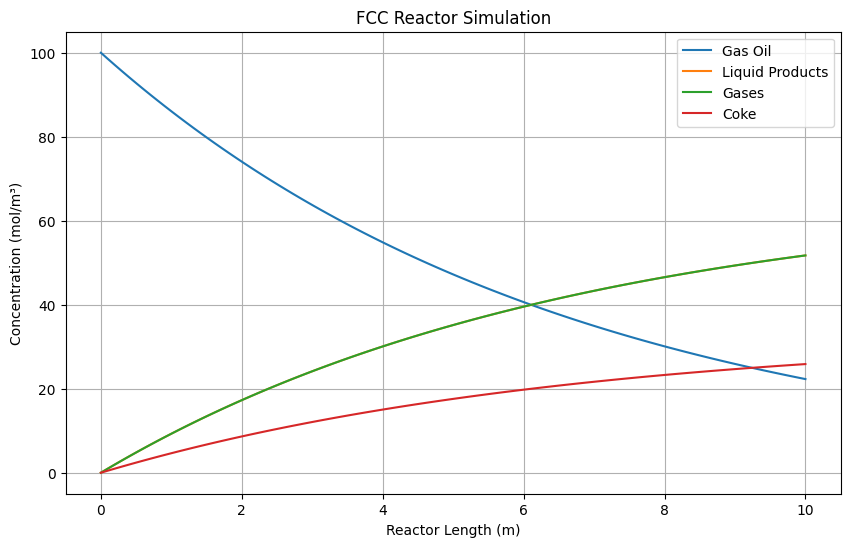

In [8]:
# Plot results
plt.figure(figsize=(10, 6))
plt.plot(z, C_gas_oil, label='Gas Oil')
plt.plot(z, C_liquid, label='Liquid Products')
plt.plot(z, C_gases, label='Gases')
plt.plot(z, C_coke, label='Coke')
plt.xlabel('Reactor Length (m)')
plt.ylabel('Concentration (mol/m³)')
plt.title('FCC Reactor Simulation')
plt.legend()
plt.grid()
plt.show()